# Miguel Baños Baladrón
# Pablo Díaz Blanco
### Grupo de prácticas 1.1
### Principios de Visión por Computador

# Ejercicio 1.- Segmentación de carreteras en imagen aérea de alta resolución

# Importaciones

In [41]:
import os
import numpy as np
from skimage import io
from skimage.color import rgb2gray
from skimage.filters import sobel
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt

# Cargar Imágenes

In [19]:
BASE_PATH = "roads" # carpeta base 
SAT_PATH = os.path.join(BASE_PATH, "sat") # subcarpeta con las fotos de satélite
GT_PATH  = os.path.join(BASE_PATH, "gt") # subcarpeta con las máscaras binarias de etiqueta

sat_images = []
gt_masks = []

# Obtenemos los nombres de los archivos ordenados para hacer coincidir imagen con etiqueta
sat_files = []
for f in os.listdir(SAT_PATH):
    sat_files.append(f)
sat_files = sorted(sat_files)

gt_files  = []
for f in os.listdir(GT_PATH):  
    gt_files.append(f)
gt_files = sorted(gt_files)

# Para cada par imagen-etiqueta, accedemos a ellos, los leemos y los añadimos a sus correspondiente lista.
for sat, gt in zip(sat_files, gt_files):
    sat_path = os.path.join(SAT_PATH, sat)
    gt_path  = os.path.join(GT_PATH, gt)
    sat_img = io.imread(sat_path)
    gt_img  = io.imread(gt_path)
    sat_images.append(sat_img)
    gt_masks.append(gt_img)

# Se transforman en arrays de numpy para operar más rápido con ellas.
sat_images = np.array(sat_images)
gt_masks   = np.array(gt_masks)

print("Datos cargados correctamente:")
print("Satélites:", sat_images.shape)
print("Máscaras:", gt_masks.shape)

Datos cargados correctamente:
Satélites: (20, 1500, 1500, 3)
Máscaras: (20, 1500, 1500)


# Preprocesado

In [25]:
# Comprobamos los valores de las máscaras, las necesitamos en 0 o en 1.
print("Original:", np.unique(gt_masks))
# Así, convertimos todo lo que es 0 en False, y lo mayor a 0 en True. Pasándolo a uint8, False pasa a 0 y True a 1, como buscamos.
gt_masks_p = (gt_masks > 0).astype(np.uint8)
print("Máscara que usaremos:", np.unique(gt_masks_p)) # Ahora debería salir [0 1]

Original: [  0 255]
Máscara que usaremos: [0 1]


In [26]:
# Ahora con las imágenes de satélite
print("Tipo original:", sat_images.dtype)
print("Mínimo original:", sat_images.min())
print("Máximo original:", sat_images.max())

# Las convertimos a float32 y normalizamos a [0, 1]
sat_images_p = sat_images.astype(np.float32) / 255.0

# Comprobamos
print("Tipo procesado:", sat_images_p.dtype)
print("Mínimo procesado:", sat_images_p.min())
print("Máximo procesado:", sat_images_p.max())

Tipo original: uint8
Mínimo original: 0
Máximo original: 255
Tipo procesado: float32
Mínimo procesado: 0.0
Máximo procesado: 1.0


# PRIMER MODELO PARA PREDECIR CARRETERAS

# Vector de características

In [29]:
def obtain_features(image):
    # Canales
    R = image[:,:,0]
    G = image[:,:,1]
    B = image[:,:,2]

    # Escala de gris
    image_gray = rgb2gray(image)

    # Bordes con Sobel
    grad_sobel = sobel(image_gray)

    return R,G,B,image_gray,grad_sobel

# Construir dataset con X características e Y etiquetas

In [30]:
NUM_PIXELS_PER_IMAGE = 5000 

X_list = []  # cada elemento será un vector de características de un píxel
y_list = []  # cada elemento será la etiqueta (0 fondo, 1 carretera)

num_images = sat_images_p.shape[0]

for i in range(num_images):
    img  = sat_images_p[i]   # (H, W, 3)
    mask = gt_masks_p[i]     # (H, W)
    
    R, G, B, gray, grad = obtain_features(img)
    
    H, W = gray.shape
    total_pixels = H * W
    
    # nº de píxeles que vamos a usar de esta imagen
    num_samples = min(NUM_PIXELS_PER_IMAGE, total_pixels)
    
    # índices aleatorios planos [0, H*W)
    flat_indices = np.random.choice(total_pixels, size=num_samples, replace=False)
    
    # pasamos a coordenadas (fila, columna)
    rows = flat_indices // W
    cols = flat_indices %  W
    
    for r, c in zip(rows, cols):
        # vector de características del píxel (r,c)
        feat = [
            R[r, c],
            G[r, c],
            B[r, c],
            gray[r, c],
            grad[r, c]
        ]
        X_list.append(feat)
        
        # etiqueta = valor de la máscara en ese píxel (0 o 1)
        y_list.append(mask[r, c])

# pasamos a arrays de NumPy
X = np.array(X_list, dtype=np.float32)  # (N, 5)
y = np.array(y_list, dtype=np.uint8)    # (N,)

print("Shape X (muestras, características):", X.shape)
print("Shape y (muestras,):", y.shape)
print("Primer vector de características:", X[0])
print("Etiqueta correspondiente:", y[0])

Shape X (muestras, características): (100000, 5)
Shape y (muestras,): (100000,)
Primer vector de características: [0.39607844 0.30980393 0.2901961  0.32672355 0.04238502]
Etiqueta correspondiente: 0


# Dividir en train/val/test

In [35]:

# 1) Train (60%) y Temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,        # 40% se queda para val+test
    random_state=42,      # semilla
    stratify=y            # mantiene proporción de clases
)

# 2) 20% val y 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,        # mitad para test, mitad para val
    random_state=42,
    stratify=y_temp
)

print("Tamaños finales:")
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape,   y_val.shape)
print("Test: ", X_test.shape,  y_test.shape)

Tamaños finales:
Train: (60000, 5) (60000,)
Val:   (20000, 5) (20000,)
Test:  (20000, 5) (20000,)


# Probar Random Forest

In [38]:
# Creamos el modelo
rf_clf = RandomForestClassifier(
    n_estimators=100,       # nº de árboles
    max_depth=None,        # sin límite de profundidad
    n_jobs=-1,             # usa todos los cores disponibles
    class_weight="balanced", # da más peso a la clase minoritaria
    random_state=42
)

# Entrenamos con el conjunto de entrenamiento
rf_clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# Predicciones en validación
y_val_pred = rf_clf.predict(X_val)

# Algunas métricas básicas
acc  = accuracy_score(y_val, y_val_pred)
prec = precision_score(y_val, y_val_pred, pos_label=1)
rec  = recall_score(y_val, y_val_pred, pos_label=1)
f1   = f1_score(y_val, y_val_pred, pos_label=1)

print("Accuracy:", acc)
print("Precision (carretera):", prec)
print("Recall (carretera):", rec)
print("F1 (carretera):", f1)

print("\nClassification report:")
print(classification_report(y_val, y_val_pred, target_names=["fondo", "carretera"]))

Accuracy: 0.9617
Precision (carretera): 0.44495412844036697
Recall (carretera): 0.1307277628032345
F1 (carretera): 0.20208333333333334

Classification report:
              precision    recall  f1-score   support

       fondo       0.97      0.99      0.98     19258
   carretera       0.44      0.13      0.20       742

    accuracy                           0.96     20000
   macro avg       0.71      0.56      0.59     20000
weighted avg       0.95      0.96      0.95     20000



### En las métricas, podemos ver el efecto del desbalanceo de las clases (19258 pixeles de fondo y 742 de carretera), al tener valores buenísimos detectando fondo y malos detectando carreteras. Básicamente, detecta el 13% de las carreteras reales y solo acierta un 44% de las veces que dice carretera. 

# Visualizar Resultados

In [40]:
def predict_mask_for_image(model, img):
    # Sacamos mapas de características
    R, G, B, gray, grad = obtain_features(img)

    H, W = gray.shape

    # Apilamos las features en un array (H, W, n_features)
    feature_stack = np.stack([R, G, B, gray, grad], axis=-1)  # (H, W, 5)

    # Aplanamos a (H*W, n_features) para pasar al modelo
    X_img = feature_stack.reshape(-1, feature_stack.shape[-1])  # (H*W, 5)

    # Predicción para todos los píxeles
    y_pred_flat = model.predict(X_img)  # (H*W,)

    # Reconstruimos la máscara 2D
    y_pred = y_pred_flat.reshape(H, W)

    return y_pred

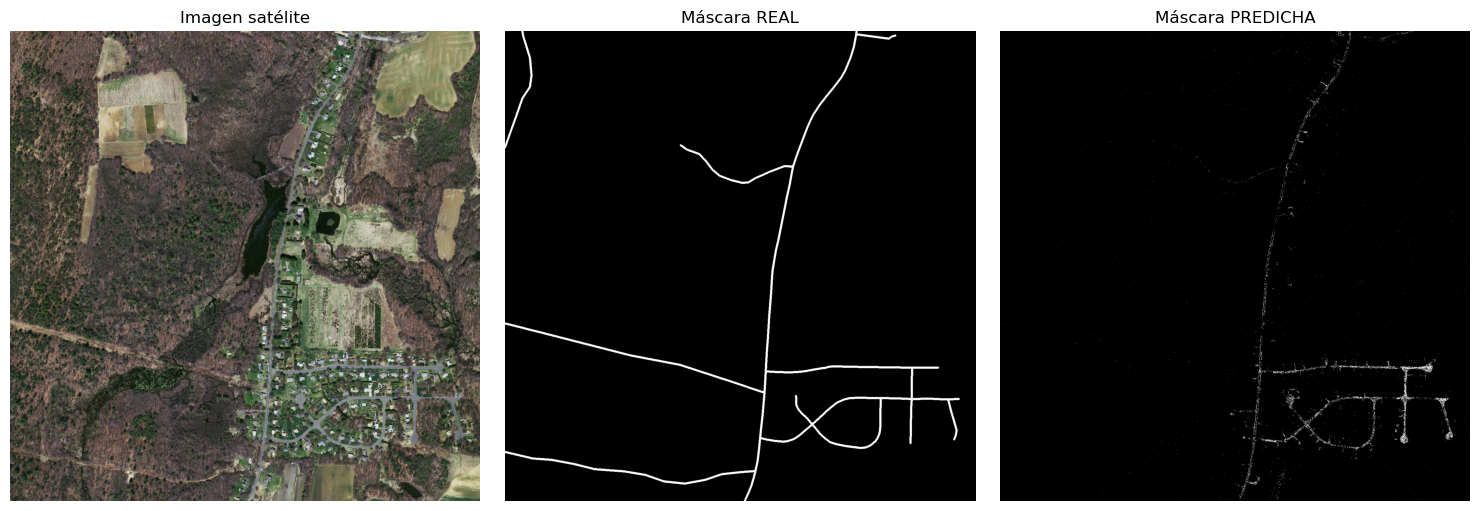

In [ ]:
i = 0 # índice de la imagen que se quiere visualizar

img  = sat_images_p[i]    # (H, W, 3)
mask = gt_masks_p[i]      # (H, W)

# Predicción del modelo
pred_mask = predict_mask_for_image(rf_clf, img)

# Mostrar resultados
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Imagen satélite")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Máscara REAL")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred_mask, cmap="gray")
plt.title("Máscara PREDICHA")
plt.axis("off")

plt.tight_layout()
plt.show()